In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2024-05-01    18
2024-05-02     4
2024-05-03    -3
2024-05-04    10
2024-05-05     8
2024-05-06    12
2024-05-07     0
2024-05-08     0
2024-05-09    13
2024-05-10    25
2024-05-11    13
2024-05-12    -8
2024-05-13    11
2024-05-14    -9
2024-05-15    13
Freq: D, dtype: int32
Тип индекса: <class 'pandas.DatetimeIndex'>

Разница температур между днями:
2024-05-01     NaN
2024-05-02   -14.0
2024-05-03    -7.0
2024-05-04    13.0
2024-05-05    -2.0
2024-05-06     4.0
2024-05-07   -12.0
2024-05-08     0.0
2024-05-09    13.0
2024-05-10    12.0
2024-05-11   -12.0
2024-05-12   -21.0
2024-05-13    19.0
2024-05-14   -20.0
2024-05-15    22.0
Freq: D, dtype: float64

Дни с изменением температуры > 5 градусов:
2024-05-02   -14.0
2024-05-03    -7.0
2024-05-04    13.0
2024-05-07   -12.0
2024-05-09    13.0
2024-05-10    12.0
2024-05-11   -12.0
2024-05-12   -21.0
2024-05-13    19.0
2024-05-14   -20.0
2024-05-15    22.0
dtype: float64



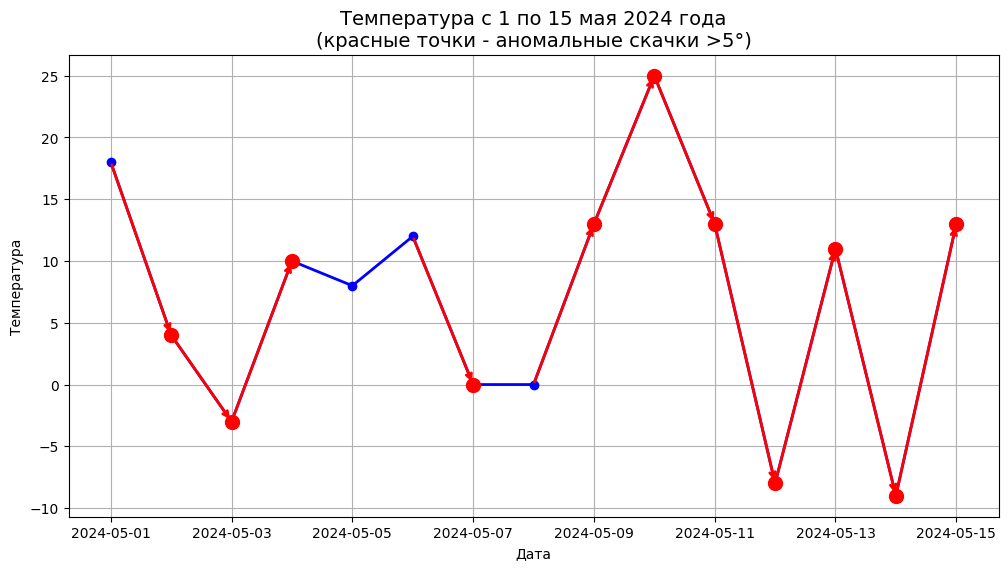

In [8]:
dates = pd.date_range(start='2024-05-01', periods=15, freq='D')
np.random.seed(42)  
temperatures = np.random.randint(-10, 26, 15)
s = pd.Series(temperatures, index=dates)
print(s)
s.index = pd.to_datetime(s.index)
print("Тип индекса:", type(s.index))
print()
temp_diff = s.diff()
print("Разница температур между днями:")
print(temp_diff)
print()
anomaly_days = temp_diff[abs(temp_diff) > 5]
print("Дни с изменением температуры > 5 градусов:")
print(anomaly_days)
print()
plt.figure(figsize=(12, 6))
plt.plot(s.index, s.values, marker='o', linestyle='-', linewidth=2,
         markersize=6, color='blue', label='Температура')
for date in anomaly_days.index:
    plt.scatter(date, s[date], color='red', s=100, zorder=5)
    prev_date = date - pd.Timedelta(days=1)
    if prev_date in s.index:
        plt.annotate('', xy=(date, s[date]),
                     xytext=(prev_date, s[prev_date]),
                     arrowprops=dict(arrowstyle='->', color='red',
                                     lw=2))
plt.title('Температура с 1 по 15 мая 2024 года\n(красные точки - аномальные скачки >5°)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid(True)

plt.show()